In [1]:
# =========================
# LIBRERÍAS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [2]:
# =========================
# CARGA DE DATOS
# =========================
df = pd.read_csv('../data/construction_cost_dataset_pro.csv')

df.head()

,proyecto,tipo_obra,fase,actividad,material,cantidad_material,costo_unitario,costo_material,horas_trabajadas,costo_mano_obra,costo_estimado,costo_real,diferencia_costo,porcentaje_desviacion,duracion_estimada,duracion_real,retraso_dias,ciudad,clima
0,Proyecto_2,Residencial,Instalaciones,Encofrado,Arena,47,15192,714024,147,2786385,3500409,4898557,1398148,39.942418,5,2,-3,Cali,Soleado
1,Proyecto_15,Industrial,Cimentación,Vaciado concreto,Arena,264,55413,14629032,156,1640496,16269528,15011427,-1258101,-7.732867,15,24,9,Barranquilla,Nublado
2,Proyecto_2,Residencial,Cimentación,Vaciado concreto,Cemento,362,43878,15883836,151,2132271,18016107,24879468,6863361,38.095694,27,33,6,Bogotá,Lluvia
3,Proyecto_18,Comercial,Instalaciones,Encofrado,Cemento,125,10431,1303875,131,1119002,2422877,2800456,377579,15.583911,11,13,2,Medellín,Soleado
4,Proyecto_5,Comercial,Instalaciones,Instalación eléctrica,Acero,36,11844,426384,90,960210,1386594,1137704,-248890,-17.949739,23,20,-3,Medellín,Soleado


In [3]:
# Información general
df.info()

# Estadísticas
df.describe()

# Valores nulos
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   proyecto               10000 non-null  str    
 1   tipo_obra              10000 non-null  str    
 2   fase                   10000 non-null  str    
 3   actividad              10000 non-null  str    
 4   material               10000 non-null  str    
 5   cantidad_material      10000 non-null  int64  
 6   costo_unitario         10000 non-null  int64  
 7   costo_material         10000 non-null  int64  
 8   horas_trabajadas       10000 non-null  int64  
 9   costo_mano_obra        10000 non-null  int64  
 10  costo_estimado         10000 non-null  int64  
 11  costo_real             10000 non-null  int64  
 12  diferencia_costo       10000 non-null  int64  
 13  porcentaje_desviacion  10000 non-null  float64
 14  duracion_estimada      10000 non-null  int64  
 15  duracion_real 

proyecto                 0
tipo_obra                0
fase                     0
actividad                0
material                 0
cantidad_material        0
costo_unitario           0
costo_material           0
horas_trabajadas         0
costo_mano_obra          0
costo_estimado           0
costo_real               0
diferencia_costo         0
porcentaje_desviacion    0
duracion_estimada        0
duracion_real            0
retraso_dias             0
ciudad                   0
clima                    0
dtype: int64

In [4]:
# Eliminar duplicados
df = df.drop_duplicates()

# Convertir fechas si aplica
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])

In [5]:
# =========================
# KPIs
# =========================
total_cost = df['costo_real'].sum()
avg_cost = df['costo_real'].mean()
total_overcost = df['diferencia_costo'].sum()
avg_delay = df['retraso_dias'].mean()

print("Costo Total:", total_cost)
print("Costo Promedio:", avg_cost)
print("Sobrecosto Total:", total_overcost)
print("Retraso Promedio:", avg_delay)

Costo Total: 142425840727
Costo Promedio: 14242584.0727
Sobrecosto Total: 12830375503
Retraso Promedio: 2.9991


In [25]:
tabla_pivot = df.pivot_table(
    index='proyecto',           # filas
    columns='tipo_obra',        # columnas
    values='costo_real',        # valores
    aggfunc='sum',              # suma total
    fill_value=0                # reemplaza NaN por 0
)

tabla_pivot.head()

tipo_obra,Comercial,Industrial,Residencial
proyecto,,,
Proyecto_1,2214123423,2467139800,1956452147
Proyecto_10,2028832332,2599581505,1931698329
Proyecto_11,2642341068,2519773806,2690884532
Proyecto_12,2341197241,2559023360,2350979119
Proyecto_13,2440015036,2766265729,2799535010


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9636/359000453.py:6: SyntaxWarning: invalid escape sequence '\d'
  df_proyectos['num_proyecto'] = df_proyectos['proyecto'].str.extract('(\d+)').astype(int)


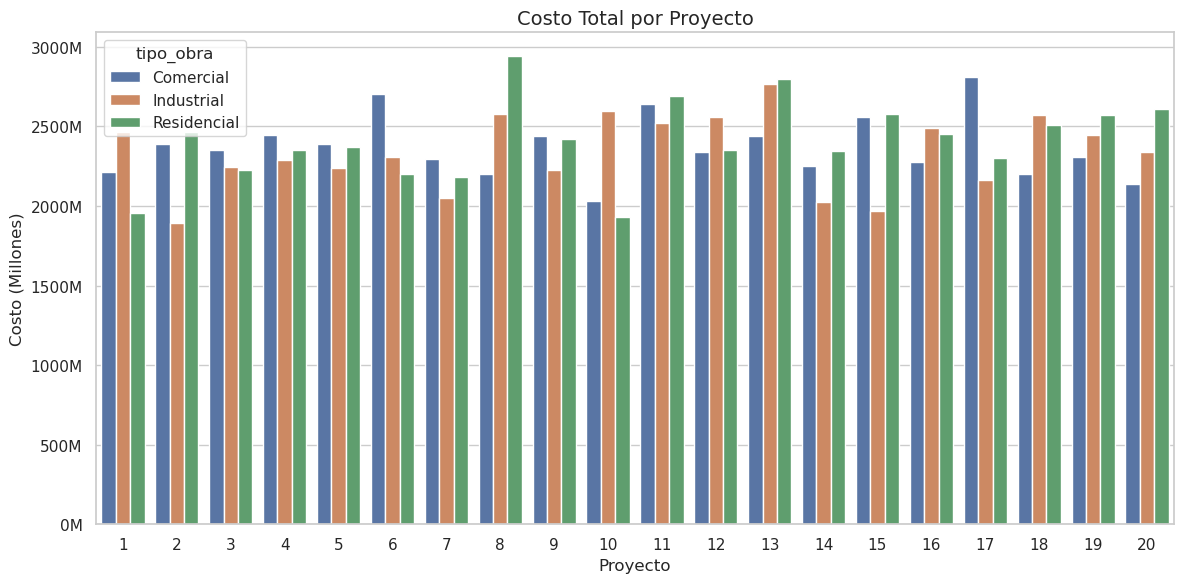

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 🔹 Extraer número del proyecto
df_proyectos['num_proyecto'] = df_proyectos['proyecto'].str.extract('(\d+)').astype(int)

# 🔹 Ordenar correctamente
df_sorted = df_proyectos.sort_values(by='num_proyecto')

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_sorted,
    x='num_proyecto',   # 👈 usamos número en vez de texto largo
    y='costo_total',
    hue='tipo_obra'
)

# 🔹 Formato en millones
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# 🔹 Etiquetas claras
plt.title("Costo Total por Proyecto", fontsize=14)
plt.xlabel("Proyecto", fontsize=12)
plt.ylabel("Costo (Millones)", fontsize=12)

# 🔹 Mejorar eje X
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

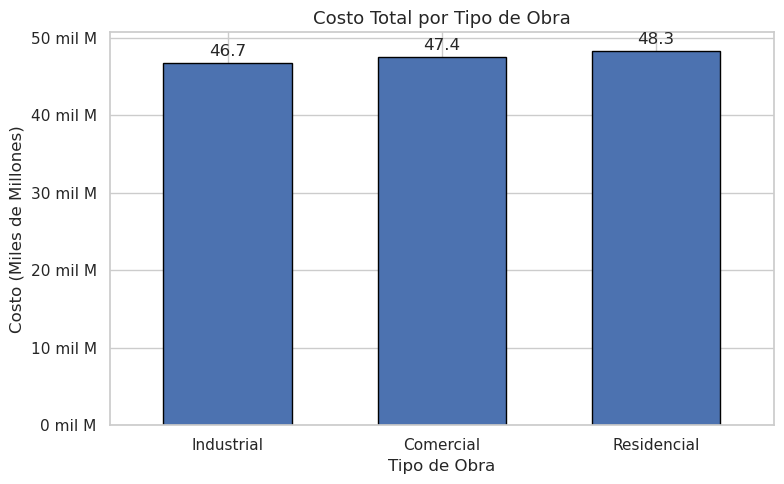

In [30]:
# 🔹 Agrupar costos por tipo de obra
costos_tipo = df.groupby('tipo_obra')['costo_real'].sum().sort_values()

plt.figure(figsize=(8,5))

# 🔹 Crear gráfico de barras (más control que seaborn)
ax = costos_tipo.plot(kind='bar', width=0.6, edgecolor='black')

# 🔹 Formato en miles de millones (evita confusión con billones)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f} mil M')
)

# 🔹 Títulos claros
plt.title("Costo Total por Tipo de Obra", fontsize=13)
plt.xlabel("Tipo de Obra")
plt.ylabel("Costo (Miles de Millones)")

# 🔹 Eje X limpio (horizontal y claro)
plt.xticks(rotation=0)

# 🔥 🔹 Agregar valores encima de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e9:.1f}' for v in costos_tipo.values],  # valor en miles de millones
        padding=3
    )

plt.tight_layout()
plt.show()

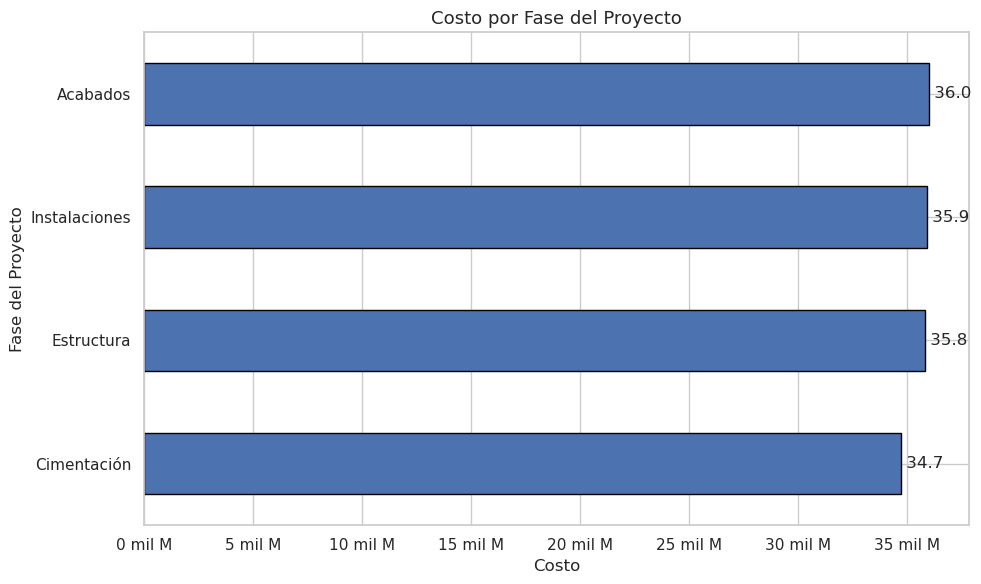

In [32]:
# 🔹 Agrupar por fase
costos_fase = df.groupby('fase')['costo_real'].sum().sort_values()

plt.figure(figsize=(10,6))

# 🔹 Gráfico horizontal
ax = costos_fase.plot(kind='barh', edgecolor='black')

# 🔥 Formato en miles de millones (igual que antes)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f} mil M')
)

# 🔹 Títulos
plt.title("Costo por Fase del Proyecto", fontsize=13)
plt.xlabel("Costo")
plt.ylabel("Fase del Proyecto")

# 🔥 Agregar valores al final de cada barra
for i, v in enumerate(costos_fase.values):
    ax.text(v, i, f' {v/1e9:.1f}', va='center')

plt.tight_layout()
plt.show()

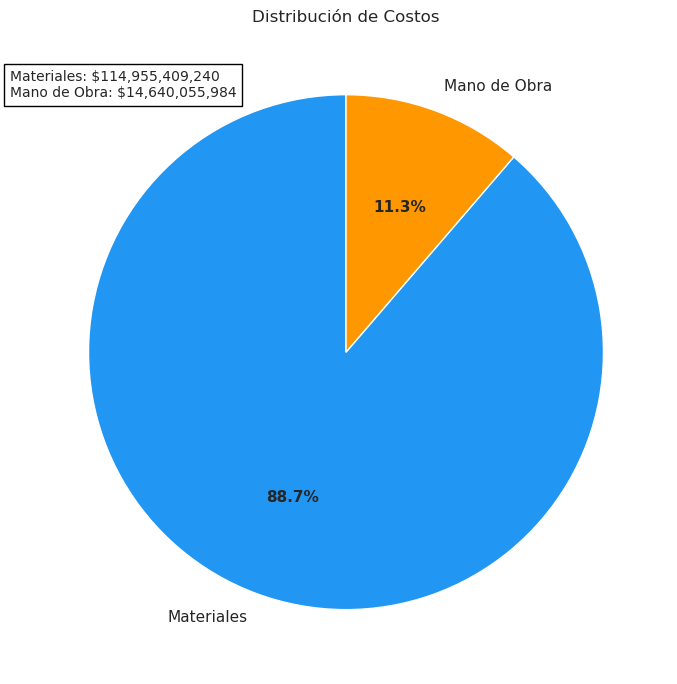

In [34]:
import matplotlib.pyplot as plt

# 🔹 Sumar costos
costos = df[['costo_material', 'costo_mano_obra']].sum()

# 🔹 Crear gráfica
plt.figure(figsize=(7,7))

colors = ['#2196F3', '#FF9800']  # azul y naranja

wedges, texts, autotexts = plt.pie(
    costos,
    labels=['Materiales', 'Mano de Obra'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Distribución de Costos")

# 🔥 🔹 Crear texto con valores reales
texto_valores = (
    f"Materiales: ${costos['costo_material']:,.0f}\n"
    f"Mano de Obra: ${costos['costo_mano_obra']:,.0f}"
)

# 🔹 Cuadro en la esquina
plt.gcf().text(
    0.02, 0.85,  # posición (izquierda, arriba)
    texto_valores,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black')
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.ylabel('')
plt.tight_layout()
plt.show()

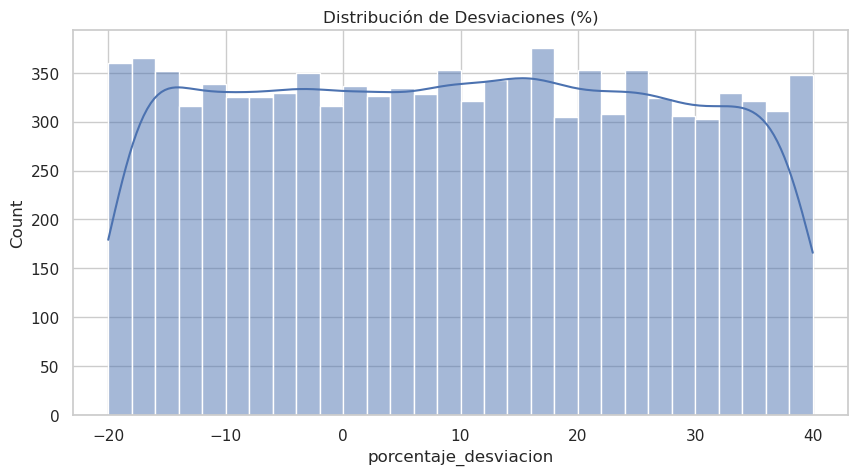

In [10]:
sns.histplot(df['porcentaje_desviacion'], bins=30, kde=True)
plt.title("Distribución de Desviaciones (%)")
plt.show()

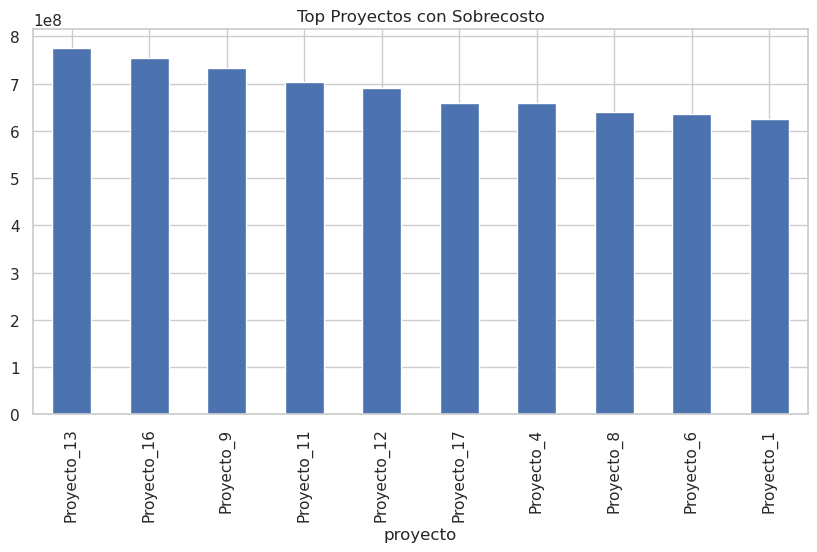

In [11]:
top_overcost = df.groupby('proyecto')['diferencia_costo'].sum().sort_values(ascending=False)

top_overcost.head(10).plot(kind='bar')
plt.title("Top Proyectos con Sobrecosto")
plt.show()

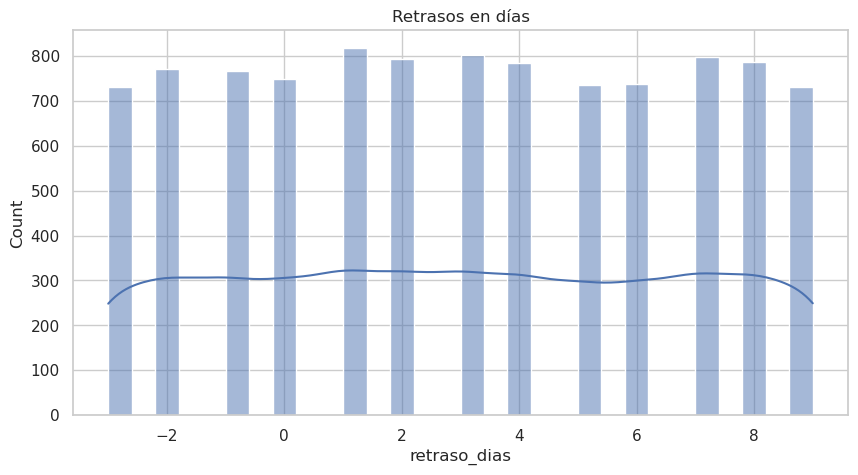

In [12]:
sns.histplot(df['retraso_dias'], bins=30, kde=True)
plt.title("Retrasos en días")
plt.show()

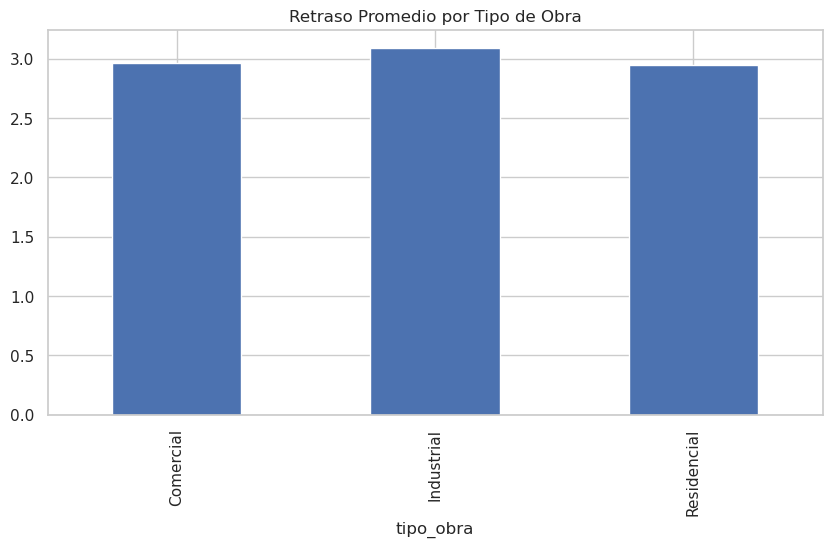

In [13]:
df.groupby('tipo_obra')['retraso_dias'].mean().plot(kind='bar')
plt.title("Retraso Promedio por Tipo de Obra")
plt.show()

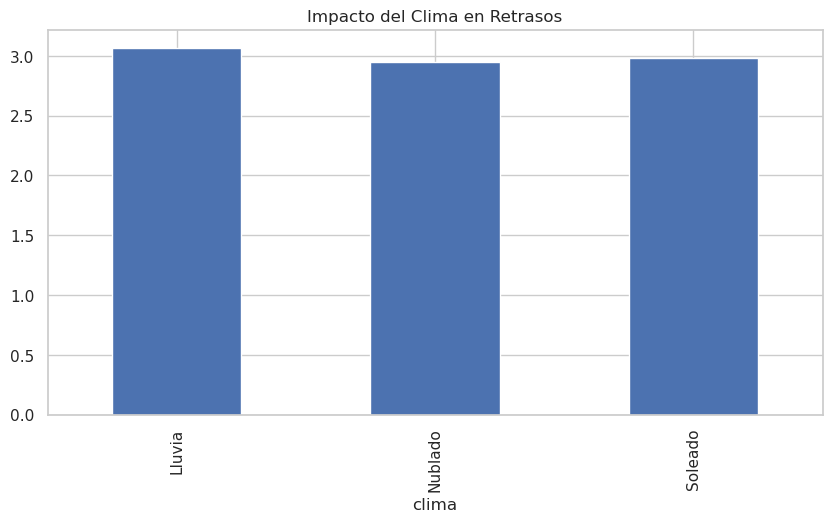

In [14]:
df.groupby('clima')['retraso_dias'].mean().plot(kind='bar')
plt.title("Impacto del Clima en Retrasos")
plt.show()

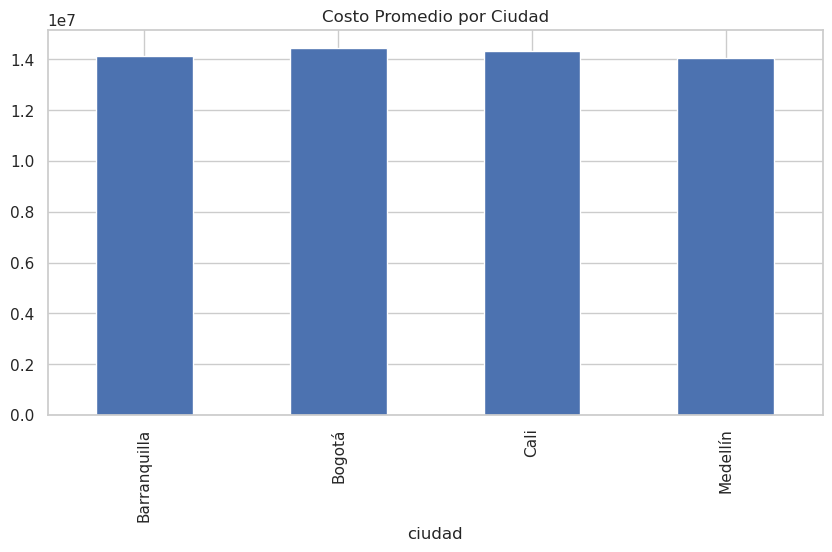

In [15]:
df.groupby('ciudad')['costo_real'].mean().plot(kind='bar')
plt.title("Costo Promedio por Ciudad")
plt.show()

## Insights Clave

- Los materiales representan la mayor proporción del costo total.
- Las fases iniciales concentran mayor inversión.
- Existe un sobrecosto promedio del X%.
- El clima lluvioso aumenta los retrasos.
- Los proyectos industriales presentan mayor costo.